In [1]:
import sys
# sys.path.append("./../")
sys.path.append("../../")
import pandas as pd

from transportnet import net
from transportnet import line
from transportnet import vehicle
from stochastic import stochastic

In [15]:
import folium
from leafmap import foliumap as leafmap

from matplotlib import pyplot as plt
from scipy import stats as ss
import numpy as np

In [2]:
df = pd.read_csv('net.txt',names=['start_name','end_name','distance'])
stops = sorted(set(df['start_name']).union(set(df['end_name'])))
graph_codes = dict(zip(stops, list(range(1, len(stops) + 1))))

In [3]:
print(len(graph_codes))
for stop in graph_codes:
    print(graph_codes[stop], stop)

107
1 Antosiewicza
2 Arena Szczecin
3 Arkońska Szpital
4 Basen Górniczy
5 Boguchwały
6 Bogumiły
7 Bohaterów Warszawy
8 Brama Portowa
9 Brzozowskiego
10 Bulwar Piastowski
11 Celna
12 Cmentarz Centralny
13 Dobromiry
14 Dubois
15 Dworcowa
16 Dworzec Niebuszewo
17 Energetyków
18 Felczaka
19 Filharmonia
20 Gocław
21 Goplana
22 Gumieńce
23 Głębokie
24 Hangarowa
25 Jaśminowa ZUS
26 Karola Miarki
27 Karłowicza
28 Kasyno
29 Kolumba
30 Konopnickiej
31 Kołłątaja
32 Krasińskiego
33 Krzekowo
34 Kręta
35 Ku Słońcu
36 Kwiatowa
37 Las Arkoński
38 Lipowa
39 Lubeckiego
40 Lubomirskiego
41 Ludowa
42 Matejki
43 Merkatora
44 Międzyparkowa
45 Modra
46 Muzeum Techniki
47 Narutowicza
48 Niemcewicza
49 Niemierzyńska Technopark
50 Osiedle Akademickie
51 Osiedle Polonia
52 Osiedle Zawadzkiego
53 Parkowa
54 Parnica
55 Piastów
56 Piotra Skargi
57 Plac Gałczyńskiego
58 Plac Grunwaldzki
59 Plac Kościuszki
60 Plac Rodła
61 Plac Szarych Szeregów
62 Plac Szyrockiego
63 Plac Tobrucki
64 Plac Witosa
65 Plac Zawiszy
66 Pl

In [4]:
def encode_graph(file, graph_codes):
    df = pd.read_csv(file, names=['start_name', 'end_name', 'distance'])
    df['start_id'] = df['start_name'].map(graph_codes)
    df['end_id'] = df['end_name'].map(graph_codes)
    df_new = df[['start_id','end_id','distance']]
    df_new.to_csv(file[:-4] + '_coded.txt', index=False, header=False, sep='\t')

In [5]:
encode_graph('net.txt', graph_codes=graph_codes)
for line_file in [f'line#{i}.csv' for i in range(1, 12)]:
    encode_graph(line_file, graph_codes=graph_codes)

In [8]:
n = net.Net()
n.load_nodes_from_file('szczecin_tram_nodes.txt')
n.load_from_file('net_coded.txt')

len(n.nodes), len(n.links)

(107, 229)

In [9]:
szczecin_lines = []
vehicles_number = [5, 5, 6, 7, 5, 5, 5, 6, 5, 5, 5]
colors = [
    "red", 
    "green", 
    "blue", 
    "yellow", 
    "magenta", 
    "cyan", 
    "orange", 
    "purple", 
    "lime", 
    "pink", 
    "gold"
]


for idx in range(1, 12):
    
    ll = [[],[]]
    
    line_t = pd.read_csv(f'line#{idx}_coded.txt', sep='\t',names=['start', 'end', 'dist'])

    llst = list(line_t['start'])

    ll[1].append(llst[0])

    ll[0]= llst

    ll[0].append(llst[0])

    stack = []

    for i in range(len(llst)):
        if llst[i] in stack:
            ll[1].append(llst[i - 1])
            break
        stack.append(llst[i])

    print(idx, ll[0], ll[1])

    next_line = line.Line(n, ll[0], ll[1])
    next_line.same_back_direction = False
    next_line.color = colors[idx - 1]
    next_line.add_vehicles([vehicle.Vehicle(110) for _ in range(vehicles_number[idx - 1])])

    szczecin_lines.append(next_line)

n.lines.extend(szczecin_lines)

1 [52, 84, 2, 73, 102, 94, 104, 6, 56, 18, 61, 58, 60, 19, 67, 8, 65, 78, 70, 78, 65, 8, 67, 19, 60, 58, 61, 18, 56, 6, 104, 94, 102, 73, 2, 84, 52] [52, 70]
2 [16, 5, 48, 31, 40, 64, 71, 60, 67, 8, 100, 11, 17, 75, 54, 43, 4, 24, 25, 92, 92, 25, 24, 4, 43, 54, 75, 17, 11, 100, 8, 67, 60, 71, 64, 40, 31, 48, 16] [16, 92]
3 [52, 84, 2, 73, 44, 79, 37, 98, 3, 99, 49, 46, 32, 31, 40, 64, 71, 60, 67, 8, 63, 74, 29, 103, 88, 106, 77, 68, 77, 106, 88, 103, 29, 74, 63, 8, 67, 60, 71, 64, 40, 31, 32, 46, 49, 99, 3, 89, 98, 37, 79, 44, 73, 2, 84, 52] [52, 68]
4 [67, 19, 60, 58, 61, 55, 59, 47, 87, 62, 51, 80, 86, 80, 51, 62, 87, 47, 59, 55, 61, 58, 60, 67] [67, 86]
5 [52, 45, 33, 107, 97, 9, 30, 69, 27, 95, 7, 55, 61, 58, 60, 42, 53, 14, 1, 82, 14, 53, 42, 60, 58, 61, 55, 7, 95, 27, 69, 30, 9, 97, 107, 33, 45, 52] [52, 82]
6 [20, 38, 105, 83, 101, 72, 41, 13, 39, 82, 14, 90, 96, 10, 100, 15, 74, 29, 103, 88, 106, 77, 68, 77, 106, 88, 103, 29, 74, 15, 100, 10, 96, 90, 14, 82, 39, 13, 41, 72, 101

In [10]:
mean_lat, mean_lon = 0, 0
for nd in n.nodes:
    mean_lat += nd.latitude
    mean_lon += nd.longitude
mean_lat /= len(n.nodes)
mean_lon /= len(n.nodes)

In [11]:
m = leafmap.Map(
    location=[mean_lat, mean_lon],
    tiles="OpenStreetMap",
    zoom_start=12
)

legend_dict = {
    f'Line #{i + 1}': colors[i]
    for i in range(11)
}

m.add_legend(legend_dict=legend_dict, title='Legend')

for ln in n.lines:

    for idx in range(len(ln.nodes)):
        nd = ln.nodes[idx]
        
        # folium.Marker(
        #     icon=folium.Icon(color='green', prefix='fa', icon='bus', size=3),
        #     location=[nd.latitude, nd.longitude],
        #     popup=nd.name
        # ).add_to(m)
        
        if idx > 0:
            pnd = ln.nodes[idx - 1]
            lnk = n.get_link(pnd, nd)
            # print(lnk, lnk.weight, lnk.track)
            # print([(pnd.latitude, pnd.longitude)] + lnk.track + [(nd.latitude, nd.longitude)])
            folium.PolyLine([(pnd.latitude, pnd.longitude)] + lnk.track + [(nd.latitude, nd.longitude)],
                        color=ln.color,
                        weight=4,
                        opacity=0.5).add_to(m)
        
        folium.CircleMarker(
            location=[nd.latitude, nd.longitude],
            popup=nd.name,
            radius = 5,
            fill=True,
            fill_color=ln.color,
            color=ln.color,
            fill_opacity=0.5
        ).add_to(m)


m.save('./szczecin_tram_net.html')

In [ ]:
n.gen_demand(30)
print(len(n.demand))

12909


In [19]:
res = []

for _ in range(100):
    n.gen_demand(30)
    res.append(n.simulate())

In [22]:
def plot_hist(res):
    xs = np.linspace(min(res), max(res), 100)
    params = ss.norm.fit(res)
    print(params)
    fig = plt.figure(dpi=150)
    ax = fig.add_subplot(1, 1, 1)
    plt.hist(res, bins=9, density=True,
             label='rozkład empiryczny')
    plt.plot(xs, ss.norm.pdf(xs, *params), linestyle='--', color='darkgreen',
             label='rozkład normalny')
    plt.axvline(res.mean(), linestyle='--', color='darkred',
                label='wartość średnia')
    plt.xlabel('Czas oczekiwania [min./pas.]')
    plt.ylabel('Częstość')
    plt.legend(fontsize=8)
    plt.show()

(6.978227227949585, 0.09692583853556609)


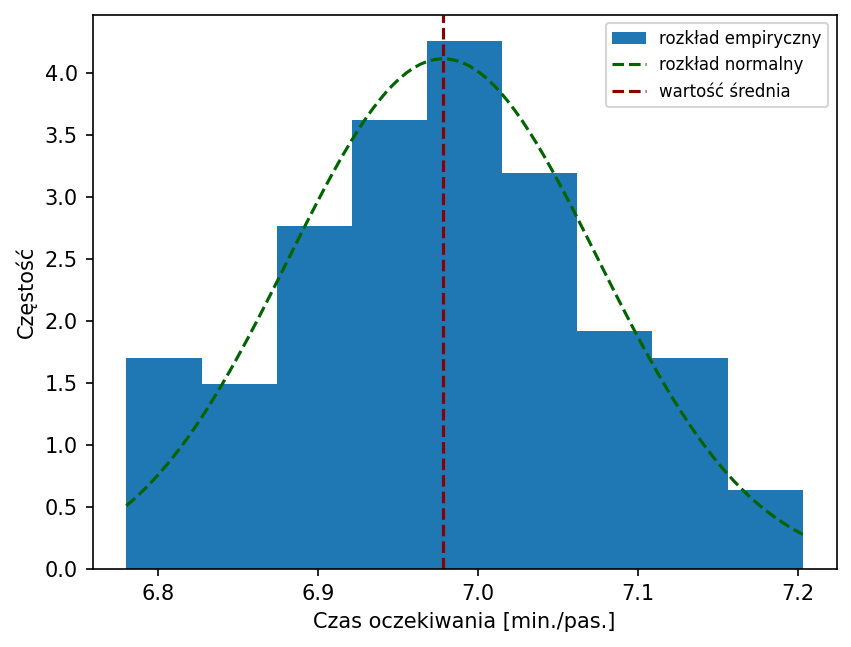

In [ ]:
plot_hist(np.array(res))